# 06 — Per-sensor track crossings: the tracker-readout route

Notebook 05 extracted the full shower cascade. **This notebook reduces it to the product this
simulation was asked to deliver**: one record per **charged-track crossing of a silicon
sensor** — where it hit, which way it was going, how fast, and what it was — for every one of
the thousands of crossings in the shower. That per-crossing table is what a detailed
sensor-level simulation (such as our collaborators' silicon charge-transport code, PIXELAV)
consumes; here we produce it and defend every field in it.

**How the crossings are obtained — the silicon is read out as a tracker.** A calorimeter
records energy deposits; it does not record a track's *momentum*. So the simulation is run
once more with the ECal silicon configured as a Geant4 **tracker** (one steering line, §2). A
tracker sensitive detector produces one `SimTrackerHit` per sensor crossing carrying exactly
what we need — **position, momentum and path length** — with no reconstruction on our part.

> **There are two complementary ways to build these crossings, and both matter (see §2b).**
> This notebook — **06** — uses the **tracker** readout, which gives the real per-crossing
> **momentum** directly. Its companion [**07**](07_sensor_crossings_calo.ipynb) builds the
> same crossings from the **calorimeter** step-energy truth (`CaloHitContribution`s,
> time-ordered): that route gives an entry-anchored position and the full step-level deposit,
> but only the *production* momentum. 06 is the route when the βγ / dE/dx regime matters (the
> momentum is real); 07 applies when only a calorimeter readout is available, or when
> step-level detail is needed — and because the two are independent readouts of the *same*
> shower, their agreement (§8) is a powerful cross-check.

**Units.** Positions and impact points in mm (sensor-local frame); momenta and energies in GeV.


## 1. What a sensor-level simulation needs — and why energy deposits are *not* it

A detailed silicon simulation (a charge-transport code such as PIXELAV) does **not** consume
Geant4's energy deposits: given a charged track's geometry and kinematics it **generates the
ionization itself**, δ-rays included, then drifts, diffuses and traps the electron–hole pairs
through the sensor's electric and magnetic fields to produce the induced pixel signal. So the
interface is **track kinematics**, per crossing, in the sensor's **local** frame (`u` across
the pitch, `v` along cylinder-z, `w` the sensor-normal / depth axis):

- the **local impact point** `(u, v)` on the sensor;
- the **direction slopes** `cot α = p_u/p_w`, `cot β = p_v/p_w` (the standard pixel-sensor
  convention for track inclination);
- the **momentum magnitude** `|p|` — it sets the βγ and therefore the dE/dx regime (a
  relativistic MIP ionizes very differently from a soft, sub-MeV electron);
- the **particle type**.

Whole-track endpoints from notebook 05 are not enough: an `MCParticle`'s vertex/endpoint
bracket its *entire* trajectory, possibly several sensors apart, whereas sensor-level
simulation works **one sensor crossing at a time**. The per-crossing truth is what we surface
here — that is the brief this notebook exists to fulfil.


## 2. The method — read the silicon out as a Geant4 tracker

The calorimeter readout writes `CaloHitContribution`s with a step's position and energy but **no
momentum** (the EDM4hep schema has no momentum field). To get the real per-crossing momentum we
map the ECal silicon to Geant4's tracker sensitive action — one line in
[`sim/run_sim_trackermom.py`](../sim/run_sim_trackermom.py):

```python
SIM.action.mapActions['ECalBarrel'] = 'Geant4TrackerWeightedAction'
```

A tracker SD combines the steps of one sensor crossing into a single **`SimTrackerHit`** carrying
`position`, **`momentum`**, `pathLength`, `eDep`, `time` and a link to the producing `MCParticle`.
That *is* one crossing record — directly, with no time-ordering reconstruction. Same gun,
physics list and random seed (424242) as the calorimeter cascade, so the shower is identical; only
the Si readout differs.

Run it on EAF (Key4hep sourced; `ddsim` needs `lib_hack` on `LD_LIBRARY_PATH`, handbook §6.3):

```bash
export LD_LIBRARY_PATH=$HOME/lib_hack:$LD_LIBRARY_PATH
ddsim --compactFile SiD_TestBeam.xml --steeringFile ../sim/run_sim_trackermom.py --numberOfEvents 1
python ../analysis/extract_trackermom.py     # -> models/trackermom_*.npz (per-crossing momentum)
python ../analysis/sensor_crossings.py       # -> models/sensor_crossings_* records (auto-selects variant C)
```

`sensor_crossings.build_segments_C` turns each `SimTrackerHit` into one crossing record. The cell
below loads them. Each record's complete field schema is documented in §7 (the hand-off).

In [1]:
import os, sys, json
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
sys.path.insert(0, os.path.abspath('../analysis'))
import sensor_crossings as sc

def _find(name):
    for base in ['../models', 'models', os.path.join(os.environ.get('CALOMAPS_HOME', '..'), 'models')]:
        p = os.path.join(base, name)
        if os.path.exists(p): return p
    return os.path.join('../models', name)

dT = np.load(_find('trackermom_gamma50_1evt.npz'), allow_pickle=True)
segs, stats = sc.build_segments_C(dT)                  # one record per SimTrackerHit crossing
print(f'{len(segs)} per-sensor crossings from {len(dT["thx"])} tracker hits; {stats}')

# unpack the payload into arrays
p_GeV  = np.array([s['p_GeV']    for s in segs])
eu     = np.array([s['entry_u']  for s in segs])       # mm, local across-pitch
ev     = np.array([s['entry_v']  for s in segs])       # mm, local cylinder-z
cota   = np.array([s['cot_alpha'] for s in segs])
cotb   = np.array([s['cot_beta']  for s in segs])
layer  = np.array([s['layer_id'] for s in segs])
pdg    = np.array([s['pdg']      for s in segs])
depthw = np.array([s['depth_w_mm'] for s in segs])
trk    = np.array([s['track_id'] for s in segs])
print(f'example record: {segs[0]}')

3217 per-sensor crossings from 3241 tracker hits; {'neutral_hits_skipped': 24, 'n_tracker_hits': 3241}
example record: {'track_id': 1, 'layer_id': 8, 'pdg': 11, 'p_GeV': 46.8992919921875, 'entry_u': 0.00016671580662463162, 'entry_v': -4.556476577411556e-05, 'cot_alpha': 0.00011181959257310972, 'cot_beta': -3.7477857425849126e-05, 'flipped': 1, 'sensor_normal_phi': 1.5707963267948966, 'depth_w_mm': 1297.0099999999998, 'energy_dep_GeV': 0.0001066317199729383, 'n_steps': 1, 'time_ns': 4.326893329620361, 'variant': 'C', 'flags': 'tracker_hit'}


## 2b. The two silicon readouts — what each stores, and what each is for

The same silicon can be read out two ways, and CALOMAPS uses **both**, for different jobs.
Side by side:

| | Calorimeter readout | Tracker readout (this notebook) |
|---|---|---|
| EDM4hep object | `SimCalorimeterHit` + `CaloHitContribution` | `SimTrackerHit` |
| Granularity | energy summed per 100 µm pixel; one contribution per Geant4 step | one hit per **sensor crossing** |
| Stores | deposited **energy**, position, time, MCParticle link | **momentum**, position (energy-weighted ≈ mid-plane), `pathLength`, `eDep`, time, MCParticle link |
| Carries momentum? | **no** (not in the schema) | **yes** |
| Steering | default (`type="calorimeter"`) | `mapActions['ECalBarrel']='Geant4TrackerWeightedAction'` |
| Used by | notebooks 01–05 and 07 | this notebook (06) |

The sensitive detector is a **passive observer** — it decides only *what is recorded*, not how
particles propagate. We verified this: the two runs (same seed) produce a **byte-identical**
MCParticle cascade (78,270 particles, identical momenta and vertices — §8). So the tracker
readout is not different physics; it is the same shower, recorded with the one field the
crossing records need — momentum — that the calorimeter schema does not carry.

**Primary vs secondary: the discriminator is the birth point, not the generator.** Every
silicon crossing in this event is a Geant4 *shower secondary* — the generator primary is the
50 GeV photon, which does not ionize — so "generator primary vs secondary" separates nothing.
What matters for a device simulation is **where the particle was born**:
- **born outside the sensor**, crossing it — an ionizing track (~88% here, median KE ~19 MeV,
  most traversing the full 320 µm). These are the tracks a single-track sensor simulation is
  built for.
- **born inside the sensor** — a delta ray knocked out by local ionization (~12%, median KE
  ~0.5 MeV, almost all with `pathLength` < 320 µm). A charge-transport code regenerates
  in-sensor delta rays itself, so these are not independent inputs.

**Division of labour:**
- **Tracker readout → per-crossing records** answers *per-crossing device physics*: cluster
  shape, charge sharing, single-hit position resolution — the device-level observables a
  detailed sensor simulation predicts.
- **Calorimeter readout → deposit-driven digitization** answers the *full-shower digital
  readout*: which pixels fire across all 30 layers (MIPs-per-pixel, clusters, shower
  profiles, the resolution fits — notebooks 01–04). This is the detector's actual measurement
  and the field-standard way to get a high-granularity calorimeter's per-pixel response
  (Allpix²-style digitization).

They are complementary, not interchangeable: summing a per-crossing device response over a
whole shower is *not* an energy-conserving readout (in-sensor delta rays would be
double-counted against the full-event calorimeter readout), and the calorimeter readout
cannot give the sub-pixel device physics. Use each for what it is for.


## 3. The local frame and two geometry choices

The ECal is a 12-sided Si–W barrel with its axis along z; each flat face's outward normal points
radially. For a crossing we rotate into the local frame where **`w`** is the sensor normal (depth),
**`u`** is across the pitch and **`v`** is the cylinder-z axis — a standard pixel-sensor local frame. Two
choices in that mapping are easy to get subtly wrong; both are fixed by the data below:

- **Where is the face?** The dodecagon could present a face *centre* or a *vertex* at +y. The hit
  azimuth peaks sharply at **90°**, so the +y beam strikes a face *centre* (`FACE_PHI0 = 0`).
  Getting this wrong by 15° would throw the local entry point off by `r·sin15° ≈ 300 mm`.
- **What labels a layer — radius or depth?** The sensors are **flat**, so a layer sits at constant
  **depth** `w` (perpendicular face distance), *not* constant radius `r=√(x²+y²)`. Assigning by
  radius mislabels wide-shower crossings into the wrong layer; assigning by **depth** keeps every
  crossing within a sub-mm of its geometric layer centre. The right panel shows both.

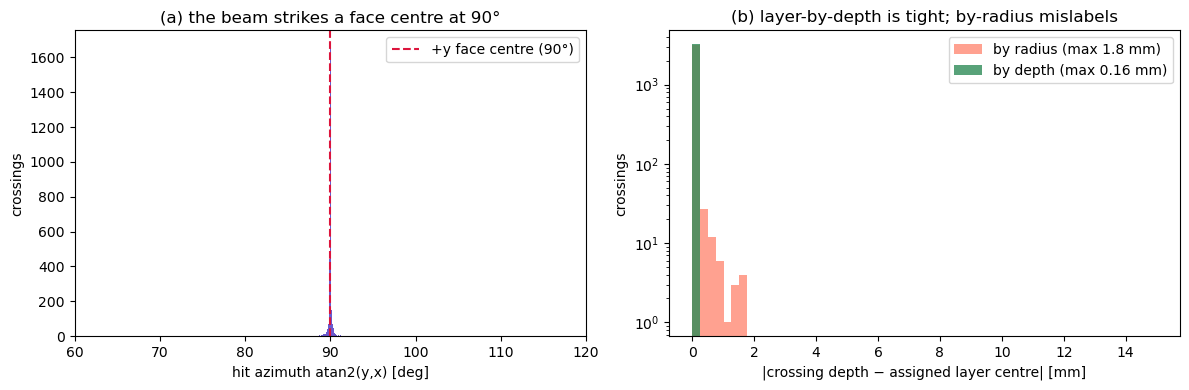

In [2]:
thx, thy = dT['thx'], dT['thy']
phin = sc.face_phi(thx, thy)
centers = sc.si_layer_centers()
wdep = thx*np.cos(phin) + thy*np.sin(phin)             # depth (face-normal projection)
r    = np.sqrt(thx**2 + thy**2)
lay_depth  = np.argmin(np.abs(wdep[:, None] - centers[None, :]), axis=1)
lay_radius = np.argmin(np.abs(r[:, None]    - centers[None, :]), axis=1)
resid_depth  = np.abs(wdep - centers[lay_depth])
resid_radius = np.abs(r    - centers[lay_radius])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.degrees(np.arctan2(thy, thx)), bins=120, color='slateblue')
ax[0].axvline(90, color='crimson', ls='--', label='+y face centre (90°)')
ax[0].set_xlabel('hit azimuth atan2(y,x) [deg]'); ax[0].set_ylabel('crossings'); ax[0].set_xlim(60, 120)
ax[0].set_title('(a) the beam strikes a face centre at 90°'); ax[0].legend()
ax[1].hist(resid_radius, bins=np.linspace(0, 15, 60), alpha=0.6, color='tomato', label=f'by radius (max {resid_radius.max():.1f} mm)')
ax[1].hist(resid_depth,  bins=np.linspace(0, 15, 60), alpha=0.8, color='seagreen', label=f'by depth (max {resid_depth.max():.2f} mm)')
ax[1].set_xlabel('|crossing depth − assigned layer centre| [mm]'); ax[1].set_ylabel('crossings')
ax[1].set_title('(b) layer-by-depth is tight; by-radius mislabels'); ax[1].legend(); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()

## 4. The payload — the per-sensor crossing records

One record per crossing, everything a sensor-level simulation needs. The four panels:

- **(a) Local impact points** — where on the sensor face each crossing sits, pooled over all
  30 layers, measured from the detector axis (`(0,0)` = the +y beam axis). The ±tens-of-mm
  spread is the shower's transverse footprint — of order the stack's Molière radius (~1 cm,
  notebook 01 §6b) — not the 100 µm pitch. The *sub-pixel* impact within a sensor is a
  separate, finer coordinate; the records carry each crossing's **real** impact, so a
  downstream consumer can use the true sub-pixel position rather than sampling one.
- **(b) Direction vs momentum** — `cot α` split into momentum bands: hard tracks pile up at
  `cot α ≈ 0` (perpendicular), soft tracks fan out — the expected EM-shower behaviour.
- **(c) Crossing-momentum spectrum** — the **real** per-crossing momentum (validated in §5).
  It rises to a peak around a few MeV: the soft sub-MeV particles born in the dense tungsten
  are absorbed before reaching silicon, so only those energetic enough to reach (and cross
  more of) the sensors register.
- **(d) Crossings per layer** — the longitudinal shower profile in track crossings: rising
  from the front, a maximum near shower-max, then the dying tail — the same depth dependence
  as the energy profile in notebooks 02/05.


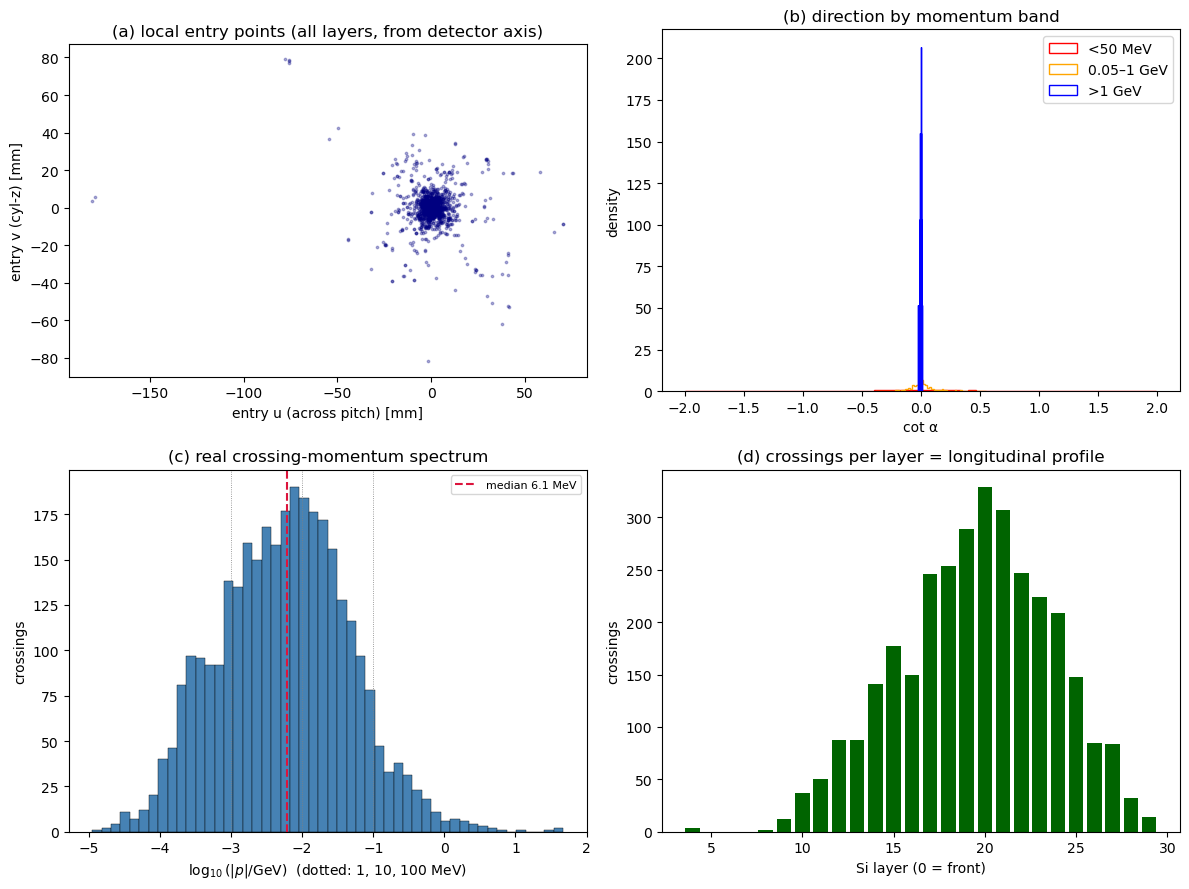

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
# (a) local entry points
ax[0,0].scatter(eu, ev, s=3, alpha=0.3, color='navy')
ax[0,0].set_xlabel('entry u (across pitch) [mm]'); ax[0,0].set_ylabel('entry v (cyl-z) [mm]')
ax[0,0].set_title('(a) local entry points (all layers, from detector axis)'); ax[0,0].set_aspect('equal')
# (b) cot alpha in momentum bands
for lo, hi, c, lab in [(0,0.05,'red','<50 MeV'),(0.05,1,'orange','0.05–1 GeV'),(1,1e9,'blue','>1 GeV')]:
    m = (p_GeV>=lo)&(p_GeV<hi)&np.isfinite(cota)&(np.abs(cota)<2)
    if m.sum(): ax[0,1].hist(cota[m], bins=60, histtype='step', color=c, label=lab, density=True)
ax[0,1].set_xlabel('cot α'); ax[0,1].set_ylabel('density'); ax[0,1].set_title('(b) direction by momentum band'); ax[0,1].legend()
# (c) momentum spectrum
pp = p_GeV[p_GeV>0]
ax[1,0].hist(np.log10(pp), bins=50, color='steelblue', edgecolor='k', lw=0.3)
ax[1,0].axvline(np.log10(np.median(pp)), color='crimson', ls='--', label=f'median {np.median(pp)*1e3:.1f} MeV')
for mev in [1, 10, 100]: ax[1,0].axvline(np.log10(mev/1e3), color='gray', ls=':', lw=0.6)
ax[1,0].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$  (dotted: 1, 10, 100 MeV)'); ax[1,0].set_ylabel('crossings'); ax[1,0].set_title('(c) real crossing-momentum spectrum'); ax[1,0].legend(fontsize=8)
# (d) crossings per layer
L = np.arange(layer.min(), layer.max()+1)
ax[1,1].bar(L, [np.sum(layer==l) for l in L], color='darkgreen')
ax[1,1].set_xlabel('Si layer (0 = front)'); ax[1,1].set_ylabel('crossings'); ax[1,1].set_title('(d) crossings per layer = longitudinal profile')
plt.tight_layout(); plt.show()

## 5. The momentum, validated

Because the tracker hit carries the **true Geant4 momentum at the crossing**, the records do
not reuse a particle's production momentum for its deep crossings (the calorimeter route's
main limitation — see notebook [07](07_sensor_crossings_calo.ipynb)). Four checks:
- **(a)** the per-crossing momentum spectrum (real) peaks at a few MeV — the soft EM shower;
- **(b)** each crossing's momentum vs its producing particle's *production* momentum sits **on
  or below the diagonal** — the empty region *above* it is the confirmation (a point there
  would mean energy gained after birth, which cannot happen);
- **(c)** the median momentum **falls with depth** as the shower softens;
- **(d)** the leading conversion electron, crossing-by-crossing, loses momentum **overall**
  from tens of GeV as it radiates through the stack (small non-monotone steps from re-linked
  secondaries are possible).


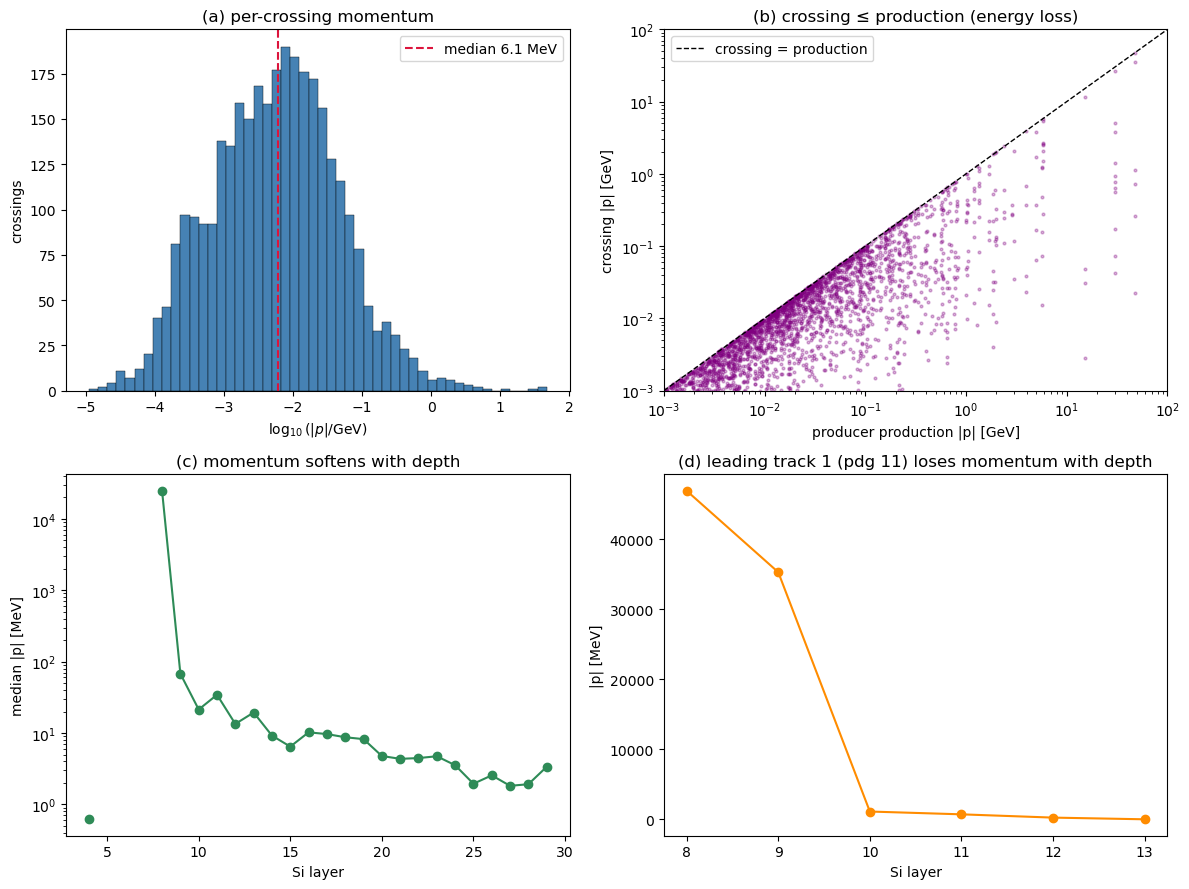

In [4]:
pprod = np.sqrt(dT['px'][trk]**2 + dT['py'][trk]**2 + dT['pz'][trk]**2)
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
m = p_GeV > 0
ax[0,0].hist(np.log10(p_GeV[m]), bins=50, color='steelblue', edgecolor='k', lw=0.3)
ax[0,0].axvline(np.log10(np.median(p_GeV[m])), color='crimson', ls='--', label=f'median {np.median(p_GeV[m])*1e3:.1f} MeV')
ax[0,0].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[0,0].set_ylabel('crossings'); ax[0,0].set_title('(a) per-crossing momentum'); ax[0,0].legend()
good = (p_GeV>0)&(pprod>0)
ax[0,1].scatter(pprod[good], p_GeV[good], s=4, alpha=0.3, color='purple')
lim=[1e-3,1e2]; ax[0,1].plot(lim,lim,'k--',lw=1,label='crossing = production')
ax[0,1].set_xscale('log'); ax[0,1].set_yscale('log'); ax[0,1].set_xlim(lim); ax[0,1].set_ylim(lim)
ax[0,1].set_xlabel('producer production |p| [GeV]'); ax[0,1].set_ylabel('crossing |p| [GeV]'); ax[0,1].set_title('(b) crossing ≤ production (energy loss)'); ax[0,1].legend()
Lp = np.arange(layer.min(), layer.max()+1)
medp = [np.median(p_GeV[layer==l]) if np.any(layer==l) else np.nan for l in Lp]
ax[1,0].plot(Lp, np.array(medp)*1e3, 'o-', color='seagreen'); ax[1,0].set_yscale('log')
ax[1,0].set_xlabel('Si layer'); ax[1,0].set_ylabel('median |p| [MeV]'); ax[1,0].set_title('(c) momentum softens with depth')
cand=[(t,(trk==t).sum(),pprod[trk==t][0]) for t in np.unique(trk)]
pool=[c for c in cand if c[1]>=3] or cand; lead=max(pool, key=lambda c:c[2])[0]
sel=trk==lead; o=np.argsort(layer[sel])
ax[1,1].plot(layer[sel][o], p_GeV[sel][o]*1e3, 'o-', color='darkorange')
ax[1,1].set_xlabel('Si layer'); ax[1,1].set_ylabel('|p| [MeV]'); ax[1,1].set_title(f'(d) leading track {lead} (pdg {dT["pdg"][lead]}) loses momentum with depth')
plt.tight_layout(); plt.show()

## 6. Geometry validation

Two consistency checks on the records. **(a)** each crossing's recorded depth minus its
assigned layer mid-plane is sub-millimetre — every crossing really sits inside the 320 µm
sensor it was labelled with. **(b)** the direction steepness `|cot| = √(cot α² + cot β²)`
versus momentum collapses to `|cot|≈0` (perpendicular) at high `|p|` and fans out at low
`|p|` — a crossing's angle is set by its momentum, as it must be. The printout reports the
inward/outward split: as expected for a forward shower **outward-going dominates**, with a
minority of inward-going backscatter (toward smaller radius); the momentum direction gives
each the correct cot **sign**, recorded in the `flipped` field (the traversal sign along the
sensor normal).


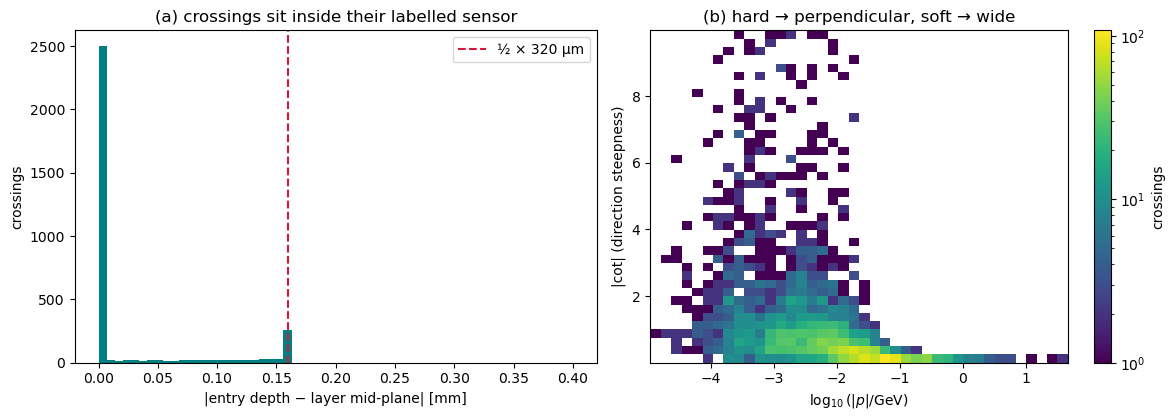

inward-going (toward smaller radius): 645;  outward-going: 2572  — momentum direction gives each the correct cot sign


In [5]:
cen = centers[layer]
resid = np.abs(depthw - cen)
cotmag = np.sqrt(cota**2 + cotb**2)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(resid, bins=np.linspace(0, 0.4, 60), color='teal'); ax[0].axvline(0.16, color='crimson', ls='--', label='½ × 320 µm')
ax[0].set_xlabel('|entry depth − layer mid-plane| [mm]'); ax[0].set_ylabel('crossings'); ax[0].set_title('(a) crossings sit inside their labelled sensor'); ax[0].legend()
mm = (p_GeV>0)&np.isfinite(cotmag)&(cotmag<10)
hb = ax[1].hist2d(np.log10(p_GeV[mm]), cotmag[mm], bins=[40,40], cmap='viridis', norm=LogNorm())
fig.colorbar(hb[3], ax=ax[1], label='crossings')
ax[1].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[1].set_ylabel('|cot| (direction steepness)'); ax[1].set_title('(b) hard → perpendicular, soft → wide')
plt.tight_layout(); plt.show()
nin = int(np.sum(np.array([s['flipped'] for s in segs])==0)); nout = len(segs)-nin
print(f'inward-going (toward smaller radius): {nin};  outward-going: {nout}  — momentum direction gives each the correct cot sign')

## 7. The hand-off — the per-crossing record schema

The validated records are serialized to plain `.json`/`.csv` tables. The full chain:

`SimTrackerHit` (Geant4) → `extract_trackermom.py` → `trackermom_*.npz` → `build_segments_C`
→ per-crossing records → `write_intermediate` → **`.json` + `.csv`**.

**The intermediate `.npz`** (`extract_trackermom.py`) holds, per tracker hit (positions in mm,
momenta in GeV): `thx, thy, thz` (global position), `tpx, tpy, tpz` (momentum), `tpath` (path
length in the sensor), `ttime` (ns), `tedep` (deposited energy), `tcellID`, and `tmc` (index
into the MCParticle arrays). The full MCParticle cascade (`pdg, mass, px, py, pz`, vertices)
is stored alongside for context and validation.

**The per-crossing record** — one dict per crossing from `build_segments_C`:

| field | type | units | meaning |
|---|---|---|---|
| `track_id` | int | — | index of the producing MCParticle |
| `layer_id` | int | 0–29 | silicon layer (0 = front) |
| `pdg` | int | — | particle type (PDG code) |
| `p_GeV` | float | GeV | real momentum magnitude at the crossing, √(tpx²+tpy²+tpz²) — not the production value |
| `entry_u`, `entry_v` | float | mm | local impact point (u across the pitch, v along cylinder-z); energy-weighted mid-crossing, ≈ mid-plane |
| `cot_alpha`, `cot_beta` | float | — | direction slopes p_u/p_w, p_v/p_w |
| `flipped` | int | 0/1 | 1 = outward-going (dw ≥ 0), 0 = inward-going (backscatter) |
| `sensor_normal_phi` | float | rad | the sensor face's outward-normal azimuth |
| `depth_w_mm` | float | mm | perpendicular depth of the impact point |
| `energy_dep_GeV` | float | GeV | energy deposited in this crossing |
| `n_steps` | int | — | 1 (the tracker action already combines a crossing's steps) |
| `time_ns` | float | ns | crossing time |
| `variant` | str | — | 'C' (tracker readout) |
| `flags` | str | — | provenance ('tracker_hit') |

Downstream consumers reformat these however their tool requires — the **`pixelav-inputs`**
branch of this repository, for example, serializes exactly these records into PIXELAV's
input-deck format for our collaborators. The cell below writes the tables and prints the
first rows.


In [6]:
models_dir = os.path.dirname(_find('trackermom_gamma50_1evt.npz'))
out_prefix = os.path.join(models_dir, 'sensor_crossings_gamma50_1evt')
jpath, cpath = sc.write_intermediate(segs, out_prefix)
print(f'wrote {len(segs)} crossing records -> {os.path.basename(jpath)}, {os.path.basename(cpath)}')
print('first rows of the CSV:')
for ln in open(cpath).read().splitlines()[:4]:
    print('  ', ln[:150])


wrote 3217 crossing records -> sensor_crossings_gamma50_1evt.json, sensor_crossings_gamma50_1evt.csv
first rows of the CSV:
   track_id,layer_id,pdg,p_GeV,entry_u,entry_v,cot_alpha,cot_beta,flipped,sensor_normal_phi,depth_w_mm,energy_dep_GeV,n_steps,time_ns,variant,flags
   1,8,11,46.8992919921875,0.00016671580662463162,-4.556476577411556e-05,0.00011181959257310972,-3.7477857425849126e-05,1,1.5707963267948966,1297.0099999
   1,9,11,35.28330993652344,0.0005199955419075863,0.00018599573537507127,-6.720234587408416e-05,0.00019763669731258544,1,1.5707963267948966,1300.75999999
   1,10,11,1.1318080425262451,-6.628520364674344e-05,0.0022913868837579838,0.002306946623249554,0.0021941019592287793,1,1.5707963267948966,1304.509999999


## 8. The two readouts are one shower, and the deposit is a real MIP

Every check above is *internal* self-consistency of the tracker readout. The two strongest checks are external to it. The calo run (notebook 07) and this tracker run share **seed 424242**, so they are the *same shower* read out two ways: if the SD change is truly a passive observer, (1) their MCParticle cascades are byte-identical, (2) their crossing counts differ only by *definition* (the tracker writes one `SimTrackerHit` per sensor *entry* while the calo groups a particle's steps per layer, so re-entrant tracks are counted differently), and (3) the two crossings-per-layer profiles trace the same longitudinal shower as notebook 05's energy profile. All shown here:

(1) MCParticle cascade: 78,270 particles, same PDG list = True, max|dp| = 0.0e+00 GeV  ->  calo & tracker read out ONE shower


(2) crossings on that shower:  tracker (06) = 3217   calo (07) = 2535   diff = 682
    the diff is entirely re-entries: 682 (particle, layer) pairs the tracker records more than once -- one SimTrackerHit per sensor ENTRY -- while the calo groups a particle's steps per layer into one crossing.
    pairs seen by only one readout: tracker-only = 0, calo-only = 0  ->  the two agree on WHICH sensors each particle hits; they differ only in counting re-entries.


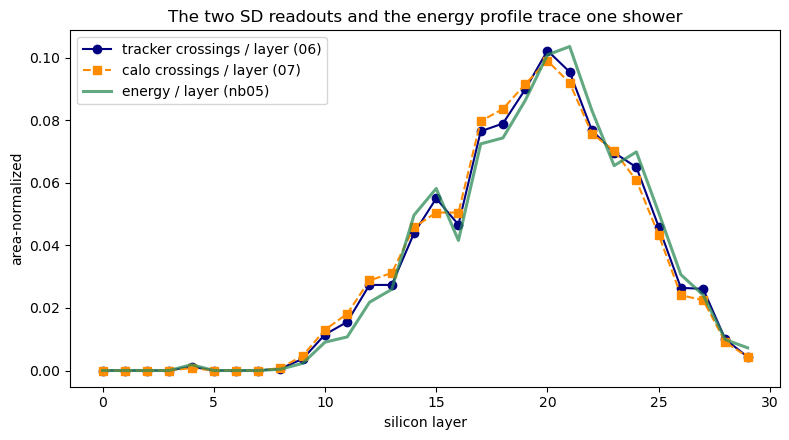

(3) longitudinal-shape correlation with the energy profile:  tracker = 0.995   calo = 0.987   (1.000 = identical shape)
(4) crossing origin:  88% entering tracks born outside the Si (median KE 19 MeV),  12% delta rays born inside a sensor (median KE 0.5 MeV)


In [7]:
import os
def _fcp():
    for b in ['../models', 'models', os.path.join(os.environ.get('CALOMAPS_HOME', '..'), 'models')]:
        p = os.path.join(b, 'fullcascade_gamma50_1evt.npz')
        if os.path.exists(p): return p
    return None
_p = _fcp()
if _p is None:
    print('fullcascade_gamma50_1evt.npz not found -- run the notebook-05 pipeline (extract_cascade.py); skipping cross-readout overlay')
else:
    dF = np.load(_p, allow_pickle=True)
    # (1) the two runs are the SAME shower: byte-identical MCParticle cascade
    same = np.array_equal(dF['pdg'], dT['pdg'])
    mdp = max(np.abs(dF['px'] - dT['px']).max(), np.abs(dF['py'] - dT['py']).max(), np.abs(dF['pz'] - dT['pz']).max())
    print(f"(1) MCParticle cascade: {len(dT['pdg']):,} particles, same PDG list = {same}, max|dp| = {mdp:.1e} GeV  ->  calo & tracker read out ONE shower")
    # (2) count reconciliation: same shower, two definitions of a crossing
    from collections import Counter
    segsA, _ = sc.build_segments_A(dF)
    kT = Counter((s['track_id'], s['layer_id']) for s in segs)
    kA = Counter((s['track_id'], s['layer_id']) for s in segsA)
    reentry = sum(v - 1 for v in kT.values() if v > 1)
    onlyT = sum(kT[k] for k in kT if k not in kA); onlyA = sum(kA[k] for k in kA if k not in kT)
    print(f"(2) crossings on that shower:  tracker (06) = {len(segs)}   calo (07) = {len(segsA)}   diff = {len(segs) - len(segsA)}")
    print(f"    the diff is entirely re-entries: {reentry} (particle, layer) pairs the tracker records more than once -- one SimTrackerHit per sensor ENTRY -- while the calo groups a particle's steps per layer into one crossing.")
    print(f"    pairs seen by only one readout: tracker-only = {onlyT}, calo-only = {onlyA}  ->  the two agree on WHICH sensors each particle hits; they differ only in counting re-entries.")
    # (3) three independent longitudinal profiles trace the same shower
    centers = sc.si_layer_centers()
    profT = np.bincount([s['layer_id'] for s in segs],  minlength=30).astype(float)
    profA = np.bincount([s['layer_id'] for s in segsA], minlength=30).astype(float)
    phin = sc.face_phi(dF['csx'], dF['csy']); wdep = dF['csx'] * np.cos(phin) + dF['csy'] * np.sin(phin)
    layE = np.argmin(np.abs(wdep[:, None] - centers[None, :]), axis=1)
    profE = np.zeros(30); np.add.at(profE, layE, dF['cE'])
    L = np.arange(30)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(L, profT / profT.sum(), 'o-', color='navy', label='tracker crossings / layer (06)')
    ax.plot(L, profA / profA.sum(), 's--', color='darkorange', label='calo crossings / layer (07)')
    ax.plot(L, profE / profE.sum(), '-', color='seagreen', lw=2.2, alpha=0.75, label='energy / layer (nb05)')
    ax.set_xlabel('silicon layer'); ax.set_ylabel('area-normalized'); ax.legend()
    ax.set_title('The two SD readouts and the energy profile trace one shower'); plt.tight_layout(); plt.show()
    cT = np.corrcoef(profT / profT.sum(), profE / profE.sum())[0, 1]
    cA = np.corrcoef(profA / profA.sum(), profE / profE.sum())[0, 1]
    print(f"(3) longitudinal-shape correlation with the energy profile:  tracker = {cT:.3f}   calo = {cA:.3f}   (1.000 = identical shape)")
    # (4) where the crossings are born: entering tracks vs in-sensor delta rays
    tmc = dT['tmc'].astype(int); ch = sc.is_charged(dT['pdg'][tmc])
    vx, vy = dT['vsx'][tmc], dT['vsy'][tmc]; pv = sc.face_phi(vx, vy); wv = vx * np.cos(pv) + vy * np.sin(pv)
    ins = np.min(np.abs(wv[:, None] - centers[None, :]), axis=1) < sc.SI_THICK_MM / 2
    KE = (dT['E'] - dT['mass'])[tmc] * 1e3
    print(f"(4) crossing origin:  {(~ins)[ch].mean() * 100:.0f}% entering tracks born outside the Si (median KE {np.median(KE[ch & ~ins]):.0f} MeV),  {ins[ch].mean() * 100:.0f}% delta rays born inside a sensor (median KE {np.median(KE[ch & ins]):.1f} MeV)")


### 8b. Absolute scale — the crossings deposit a silicon MIP

The one check that appeals to physics *outside* this pipeline: a relativistic track crossing the full 320 um sensor must deposit the silicon **MIP** — a Landau distribution whose most-probable value is ~85 keV, exactly the MIP the calo pipeline (nb01/nb02) is normalized to. `Geant4TrackerWeightedAction` records both `eDep` and `pathLength` per crossing, so we can show it directly (and confirm the SD integrates the full sensor depth, not a single pixel):

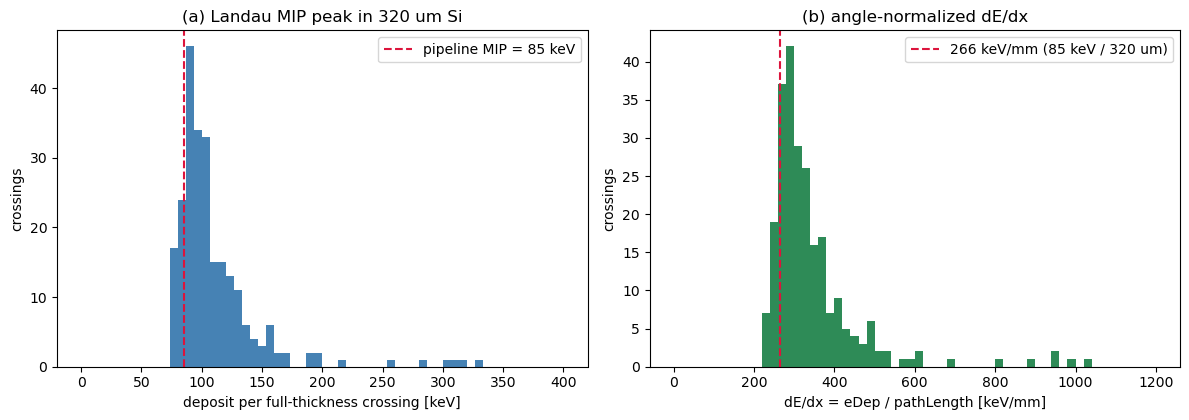

full-thickness crossings n = 244:  Landau MPV ~ 90 keV, median = 100, mean = 114 keV
-> the MPV lands on the 85 keV MIP the calo pipeline (nb01/nb02) is built on; MPV < median < mean is the Landau tail.
This ties the SD deposit to an ABSOLUTE physical scale -- external to any reconstruction in this notebook.


In [8]:
# The one EXTERNAL check: the energy each crossing leaves in the 320 um sensor must be the
# silicon MIP -- a Landau with most-probable value ~85 keV, the value nb01/nb02 normalize to.
tp = np.sqrt(dT['tpx']**2 + dT['tpy']**2 + dT['tpz']**2)      # |p| per SimTrackerHit (GeV)
tpath = np.asarray(dT['tpath']); tedep = np.asarray(dT['tedep']) * 1e6   # pathLength mm; deposit keV
rel = tp > 0.1                                                # relativistic (>100 MeV): on the MIP plateau
full = rel & (tpath > 0.30) & (tpath < 0.40)                 # near-perpendicular, ~full 320 um traversal
MIP_keV = 85.0
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(tedep[full], bins=60, range=(0, 400), color='steelblue')
ax[0].axvline(MIP_keV, color='crimson', ls='--', label=f'pipeline MIP = {MIP_keV:.0f} keV')
ax[0].set_xlabel('deposit per full-thickness crossing [keV]'); ax[0].set_ylabel('crossings')
ax[0].set_title('(a) Landau MIP peak in 320 um Si'); ax[0].legend()
dedx = tedep[rel] / tpath[rel]
ax[1].hist(dedx, bins=60, range=(0, 1200), color='seagreen')
ax[1].axvline(MIP_keV / 0.32, color='crimson', ls='--', label=f'{MIP_keV / 0.32:.0f} keV/mm (85 keV / 320 um)')
ax[1].set_xlabel('dE/dx = eDep / pathLength [keV/mm]'); ax[1].set_ylabel('crossings')
ax[1].set_title('(b) angle-normalized dE/dx'); ax[1].legend()
plt.tight_layout(); plt.show()
h, e = np.histogram(tedep[full], bins=60, range=(0, 400)); mpv = 0.5 * (e[np.argmax(h)] + e[np.argmax(h) + 1])
print(f"full-thickness crossings n = {int(full.sum())}:  Landau MPV ~ {mpv:.0f} keV, median = {np.median(tedep[full]):.0f}, mean = {np.mean(tedep[full]):.0f} keV")
print(f"-> the MPV lands on the {MIP_keV:.0f} keV MIP the calo pipeline (nb01/nb02) is built on; MPV < median < mean is the Landau tail.")
print("This ties the SD deposit to an ABSOLUTE physical scale -- external to any reconstruction in this notebook.")


## Summary & what's next

- The per-sensor crossing product is produced programmatically from the simulation: the ECal
  silicon is read out as a Geant4 **tracker**, so each `SimTrackerHit` is one crossing
  carrying the **real** impact point, direction and **momentum** —
  `analysis/sensor_crossings.py` (variant C) reshapes them into per-crossing records with
  `cot α`/`cot β`, `|p|` and particle type.
- `sensor_crossings.py` auto-selects the readout **variant**: **C** (this notebook) uses the
  tracker hit's real momentum; **A** (the calorimeter route, notebook 07) time-orders the step
  deposits and uses the production momentum; **B** is the coarsest pixel-centroid fallback.
  C is preferred wherever a tracker readout is available.
- The reconstruction choices are validated against the data: the +y face at 90°, layers
  labelled by depth, the real momentum (on/below the production diagonal, softening with
  depth), the expected hard-perpendicular / soft-wide angular behaviour — and, externally,
  the byte-identical cascade across readouts and the 85 keV silicon-MIP Landau (§8).
- **The deliverable** is the per-crossing table written in §7 (`.json`/`.csv`): position,
  direction, momentum and particle type for every charged-track crossing of every silicon
  sensor. [**07**](07_sensor_crossings_calo.ipynb) builds the same crossings from calorimeter
  step truth as a cross-check; the `pixelav-inputs` branch converts these tables into
  ready-to-run input decks for PIXELAV, our collaborators' silicon charge-transport
  simulation.
